In [2]:
from utils.dependencies import *;

# Cube setup function

Benjamin Pennell

--

Max Planck Institut für Astronomie, Heidelberg

---

The idea here is to set up all data and parameters into a single `.json` file, which will be passed as a parameter into the script `ComputeCube.py`. 
This is done for several reasons:
- speed: command-line python script is better than a notebook
- organisation: all relevant information for a particular cube can be kept in one place

The philosohy for the cubes is as follows: cubes are to be created for a particular dataset to eliminate assumptions and for the sake of computation
- sky positions and proper motions sampled from catalogue so they don't need to be assumed
- parallax binning obviously chosen for relevant parallaxes, same with apparent magnitudes
- lambda range and sampling style depending on the problem

The name of the game is responsible memory usage. There are big catalogues, and memory allocations can contribute to order-of-magnitude slower computations

## The scripts

We want to compute the grid as quickly as possible, and also stream data to be saved as things go to save on memory and to be able to resume uncompleted computations. To do this, here's the plan

We will compute the cube column-by-column. This makes the most sense since each column is roughly the same computing time as the other (which isn't the same for the rows), and the columns will be the larger axis. We will have a runner script `CreateCube.py` which will split the data into sequence and call `ComputeColumn.py` which launches jobs to parallelise the computing of that column. Here's the pseudocode for `CreateCube.py`

```python
    load config file

    split data into columns
    for each column:
        compute the column in ComputeColumn.py
        append to output data, update log
```

The main time sink is the needless orbit solutions. We can solve this in a couple ways. Here's my ideas:
- broad period cut ($P\!\in\!(1,4)$)
- first compute a coarse cube, and then prevent checking for orbit solutions where none are found
- if 250 marginalisations are done, do 100, and if no orbit solutions are found, then don't try any more.

For now, I'll implement the first and the last

## marginalisation catalogue

In [12]:
INPUT_FILE = './data/2026_06_09_final_table.fits'
main_table = Table.read(INPUT_FILE, format='fits')

## grid setup

In [18]:
NAME = "mag_scaled"
ECCENTRICITY_TYPE = "turnover"
PERIOD_RESOLUTION = 175
LAMBDA_RESOLUTION = 100
SAMPLE_COUNT = 250
TRIAL_COUNT = 100
PERIOD_LIMITS = (1,8)
LAMBDA_INDEX = 4
LAMBDA_NOTE = "sampled by power law of index {}".format(LAMBDA_INDEX)
NOTE = "Cube created from three parallaxes for turnover orbits, with a fairly fine resolution and 250 samples. Should be good for inference?"

In [15]:
def calculate_orbit_parameter(m, q, w):
    return q*w*m**(1/3)*(1 + q)**(-2/3)

def q_from_l(l, m, w):
    z = m*(w/l)**3
    q = sympy.symbols("q", real=True)
    roots = sympy.solve(z*q**3 - q**2 - 2*q - 1)
    if len(roots) == 0:
        return -1
    return roots[0]

In [16]:
period_edges = np.linspace(*PERIOD_LIMITS, PERIOD_RESOLUTION + 1) # edge of the period grid
period_grid = 0.5 * (period_edges[:-1] + period_edges[1:]) # centers of the period grid

reference_mass = np.median(main_table["mass"])
reference_parallax = np.median(main_table["parallax"])
reference_magnitude = np.median(main_table["phot_g_mean_mag"])
median_pm = np.median(np.sqrt(main_table["pmra"]**2 + main_table["pmdec"]**2))

reference_error = al_uncertainty_per_ccd_interp(reference_magnitude)
min_error = al_uncertainty_per_ccd_interp(np.min(main_table["phot_g_mean_mag"]))/reference_error
max_error = al_uncertainty_per_ccd_interp(np.max(main_table["phot_g_mean_mag"]))/reference_error

minimum_lambda = min_error*calculate_orbit_parameter(np.min(main_table["mass"]), 0.05, np.min(main_table["parallax"]))
maximum_lambda = max_error*calculate_orbit_parameter(np.max(main_table["mass"]), 0.5, np.max(main_table["parallax"]))
scaled_lambda_edges = np.linspace(minimum_lambda**(1/LAMBDA_INDEX), maximum_lambda**(1/LAMBDA_INDEX), LAMBDA_RESOLUTION + 1)
scaled_lambda_grid = 0.5 * (scaled_lambda_edges[:-1] + scaled_lambda_edges[1:])
lambda_edges = scaled_lambda_edges**LAMBDA_INDEX
lambda_grid = scaled_lambda_grid**LAMBDA_INDEX

mass_ratio_grid = np.array([q_from_l(l, reference_mass, reference_parallax) for l in lambda_grid])

In [17]:
Ntot = 100
output_arr = np.zeros(Ntot)
evens = np.flip(np.arange(Ntot))[::2]
odds = np.arange(Ntot)[::2]
output_arr[::2] = evens
output_arr[1::2] = odds

In [20]:
config_file = {
        "date": str(date.today()),
        "input_file": INPUT_FILE,
        "grid": (period_edges, lambda_edges),
        "period_grid": period_grid,
        "lambda_grid": lambda_grid,
        "mass_ratio_grid": mass_ratio_grid,
        "reference_mass": reference_mass,
        "reference_parallax": reference_parallax,
        "reference_magnitude": reference_magnitude,
        "median_pm": median_pm,
        "shape": (PERIOD_RESOLUTION, LAMBDA_RESOLUTION, SAMPLE_COUNT),
        "trial_count": TRIAL_COUNT,
        "eccentricity_type": ECCENTRICITY_TYPE,
        "note": NOTE
    }

outfile = open("./data/{}.pkl".format(NAME), "wb")
pickle.dump(config_file, outfile)
outfile.close()

# Showing what the output data looks like

In [12]:
imported_cube = pickle.load(open("./data/2026-05-08-low_mass_grid.pkl", "rb"))
comparison_cube = pickle.load(open("./data/low_mass_grid_cached.pkl", "rb"))

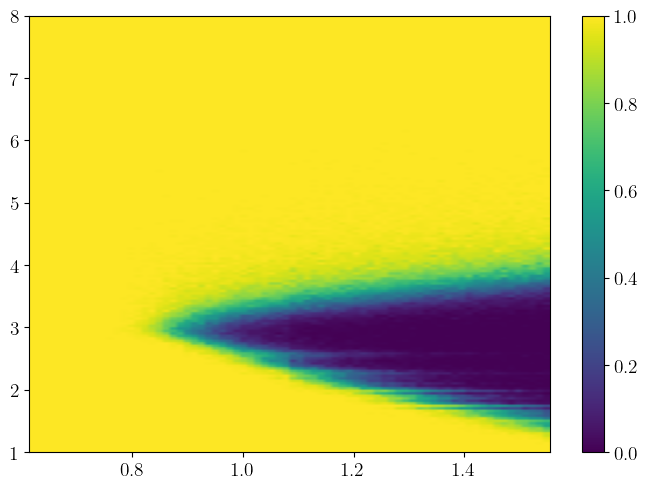

In [23]:
SOLDEX = 0
fig, ax = plt.subplots(1,1, figsize=(7,5), sharex=True)

logps = comparison_cube["meta"]["grid"][0]
yrange = (logps[-1], logps[0])

lams = comparison_cube["meta"]["grid"][1]
xrange = np.array((lams[0], lams[-1]))**(1/4)
extent = [*xrange, *yrange]
extent = [float(e) for e in extent]
cb = ax.imshow(comparison_cube["cube"][:,:,SOLDEX]/250, extent=extent, aspect="auto")
ax.invert_yaxis()

plt.colorbar(cb)
plt.tight_layout()

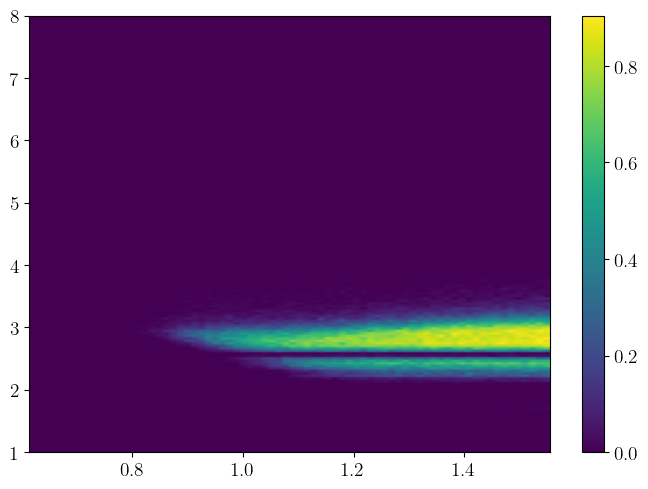

In [10]:
SOLDEX = 4
fig, ax = plt.subplots(1,1, figsize=(7,5), sharex=True)

logps = imported_cube["meta"]["grid"][0]
yrange = (logps[-1], logps[0])

lams = imported_cube["meta"]["grid"][1]
xrange = np.array((lams[0], lams[-1]))**(1/4)
extent = [*xrange, *yrange]
extent = [float(e) for e in extent]
cb = ax.imshow(imported_cube["cube"][:,:,SOLDEX]/250, extent=extent, aspect="auto")
ax.invert_yaxis()

plt.colorbar(cb)
plt.tight_layout()

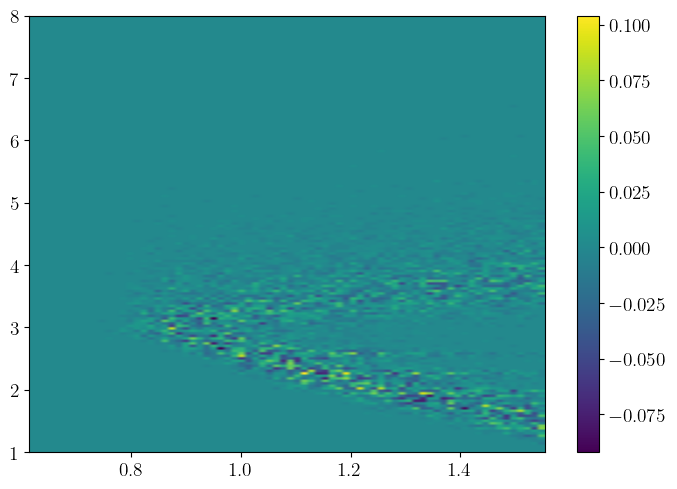

In [19]:
SOLDEX = 0
fig, ax = plt.subplots(1,1, figsize=(7,5), sharex=True)

logps = imported_cube["meta"]["grid"][0]
yrange = (logps[-1], logps[0])

lams = imported_cube["meta"]["grid"][1]
xrange = np.array((lams[0], lams[-1]))**(1/4)
extent = [*xrange, *yrange]
extent = [float(e) for e in extent]
cb = ax.imshow((imported_cube["cube"][:,:,SOLDEX]/250 - comparison_cube["cube"][:,:,SOLDEX]/250), extent=extent, aspect="auto")
ax.invert_yaxis()

plt.colorbar(cb)
plt.tight_layout()

In [2]:
imported_cube = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))

In [4]:
del imported_cube["meta"]["memory_reduced_catalogue"]

In [7]:
outfile = open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "wb")
pickle.dump(imported_cube, outfile)
outfile.close()

In [3]:
imported_cube = pickle.load(open("./data/2026-01-10-mdwarf_mbins_3plx_thermal.pkl", "rb"))

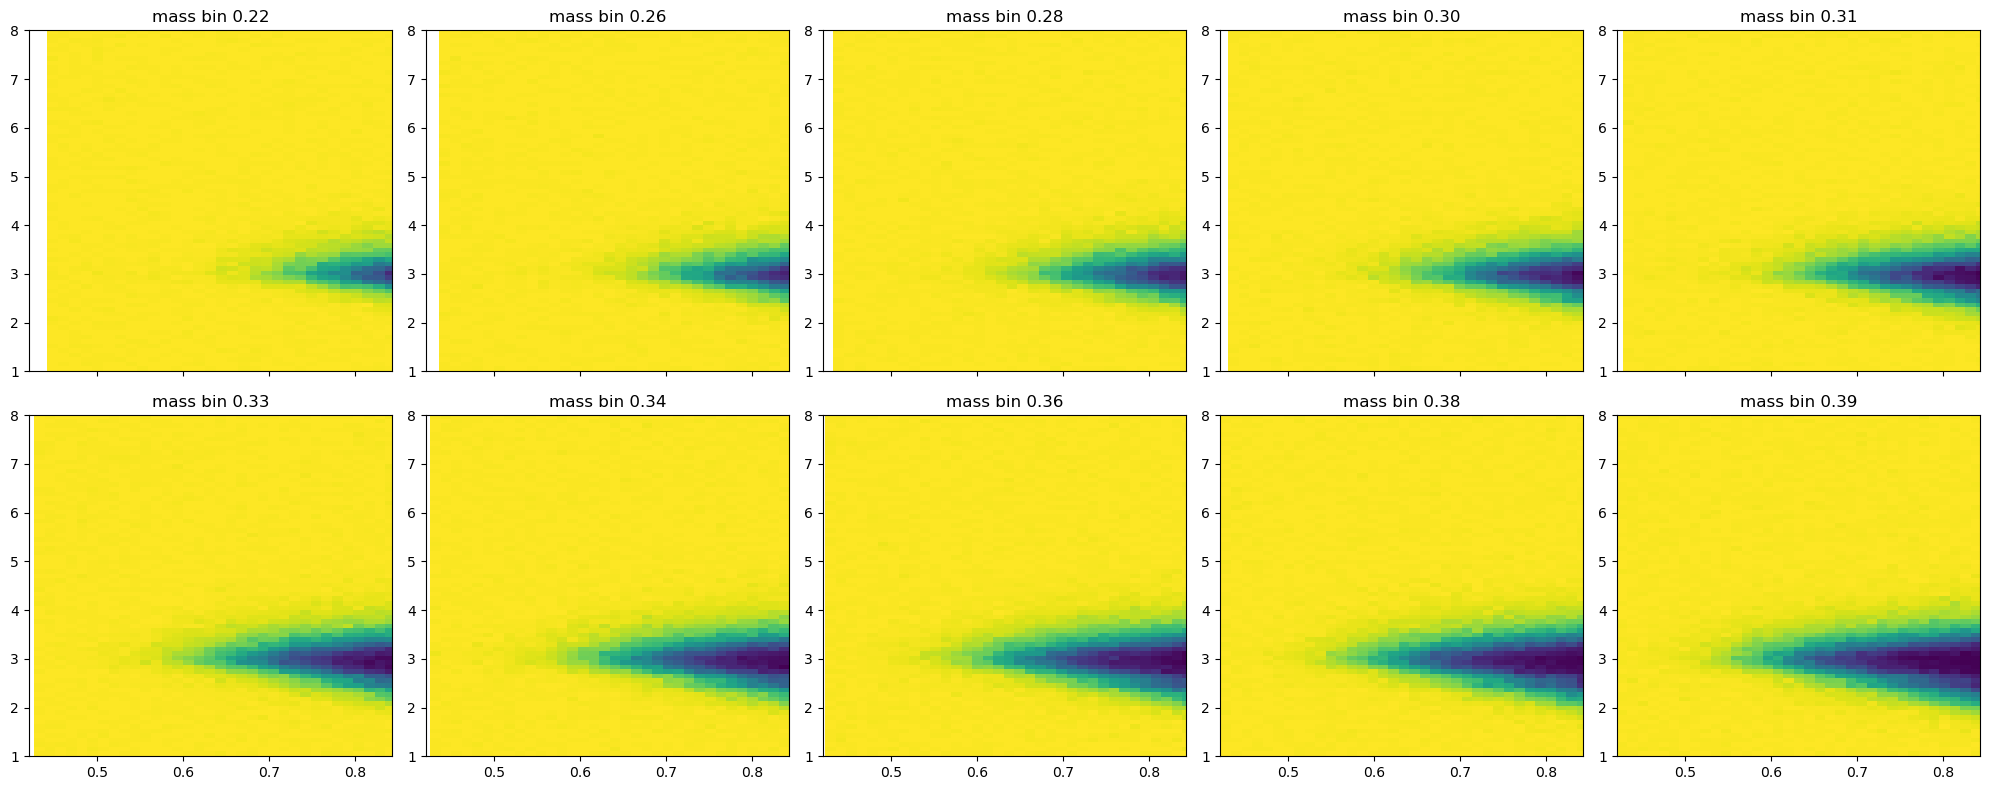

In [8]:
SOLDEX = 0
PLXDEX = 1
fig, axs = plt.subplots(2,5, figsize=(20,8), sharex=True)

logps = np.log10(imported_cube["meta"]["periods"])
yrange = (logps[-1], logps[0])

ms = list(imported_cube["data"].keys())
plx = list(imported_cube["data"][ms[0]].keys())[PLXDEX]

for i in range(10):
    ax = axs[i//5,i%5]
    lams = imported_cube["meta"]["qs"][i][PLXDEX]
    xrange = np.array((lams[0], lams[-1]))**(1/4)
    extent = [*xrange, *yrange]
    extent = [float(e) for e in extent]
    ax.imshow(imported_cube["data"][ms[i]][plx][:,:,SOLDEX], extent=extent, aspect="auto")
    ax.set_title("mass bin {:.2f}".format(ms[i]))
    ax.invert_yaxis()

plt.tight_layout()

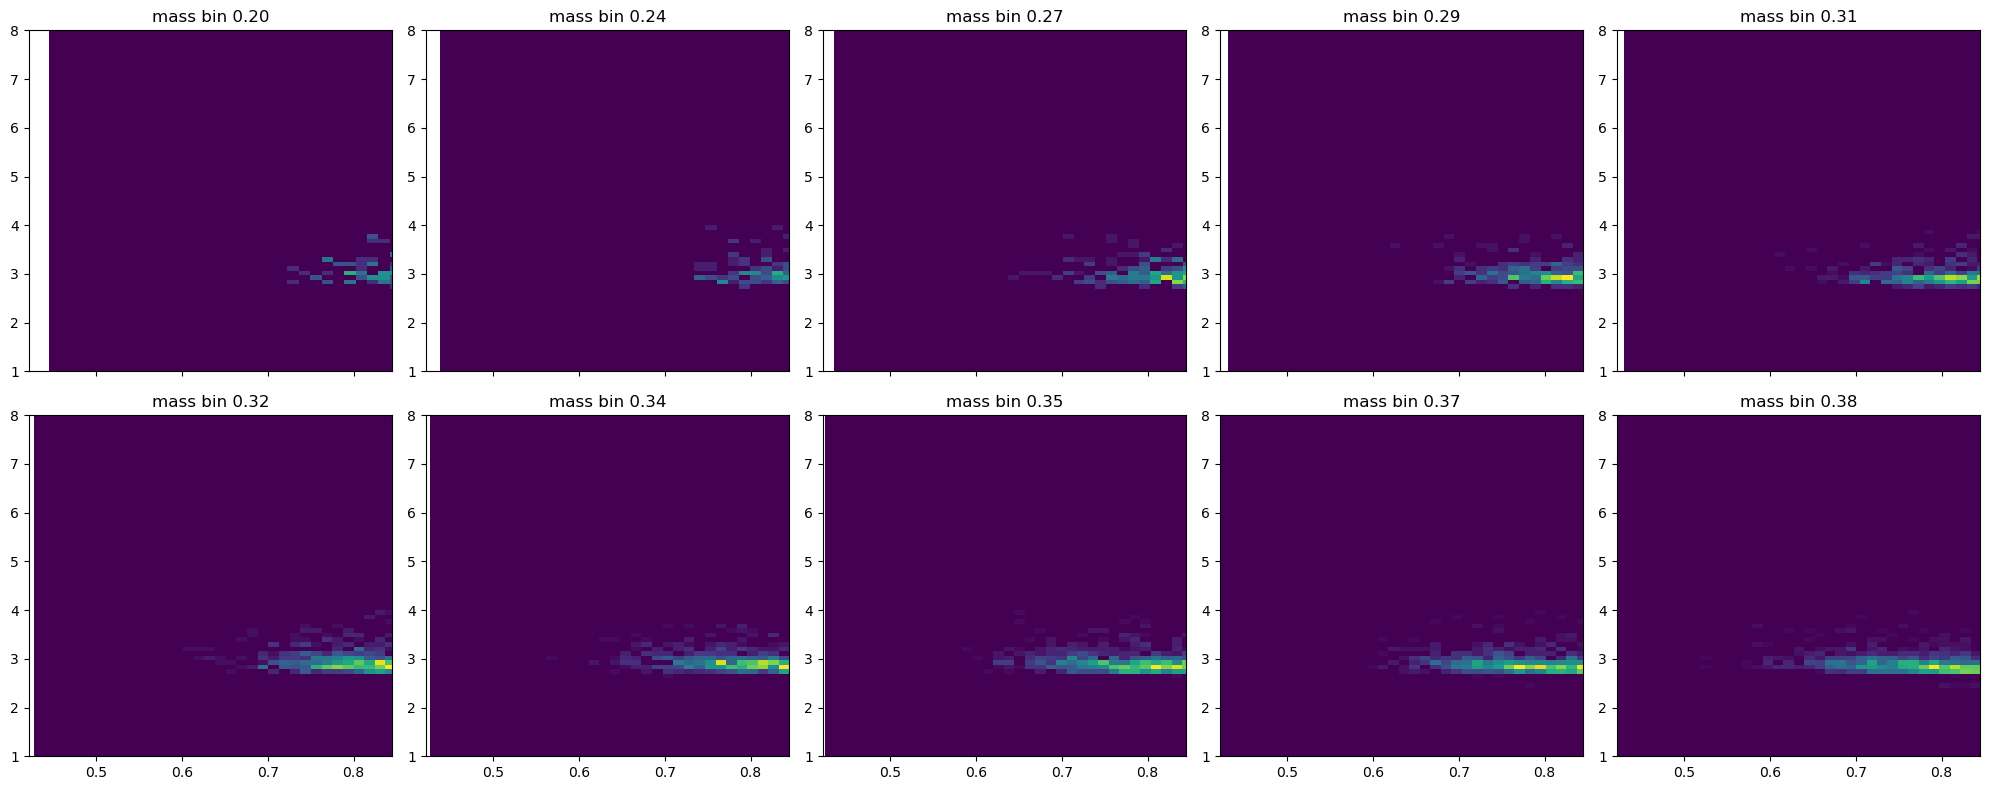

In [24]:
SOLDEX = 4
PLXDEX = 1
fig, axs = plt.subplots(2,5, figsize=(20,8), sharex=True)

logps = np.log10(imported_cube["meta"]["periods"])
yrange = (logps[-1], logps[0])

ms = list(imported_cube["data"].keys())
plx = list(imported_cube["data"][ms[0]].keys())[PLXDEX]

for i in range(10):
    ax = axs[i//5,i%5]
    lams = imported_cube["meta"]["qs"][i][PLXDEX]
    xrange = np.array((lams[0], lams[-1]))**(1/4)
    extent = [*xrange, *yrange]
    extent = [float(e) for e in extent]
    ax.imshow(imported_cube["data"][ms[i]][plx][:,:,SOLDEX], extent=extent, aspect="auto")
    ax.set_title("mass bin {:.2f}".format(ms[i]))
    ax.invert_yaxis()

plt.tight_layout()

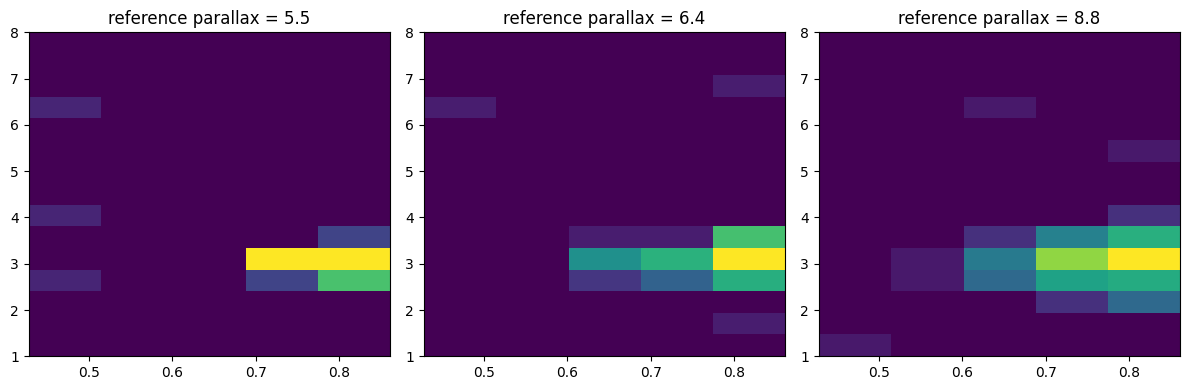

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(12,4), sharex=True)

logps = np.log10(imported_cube["meta"]["periods"])
yrange = (logps[-1], logps[0])

plxs = list(imported_cube["cube"].keys())

for i in range(3):
    lams = imported_cube["meta"]["qs"][i]
    xrange = np.array((lams[0], lams[-1]))**(1/4)
    extent = [*xrange, *yrange]
    extent = [float(e) for e in extent]
    axs[i].imshow(np.mean(imported_cube["cube"][plxs[i]], axis=2), extent=extent, aspect="auto")
    axs[i].set_title("reference parallax = {:.1f}".format(plxs[i]))
    axs[i].invert_yaxis()

plt.tight_layout()

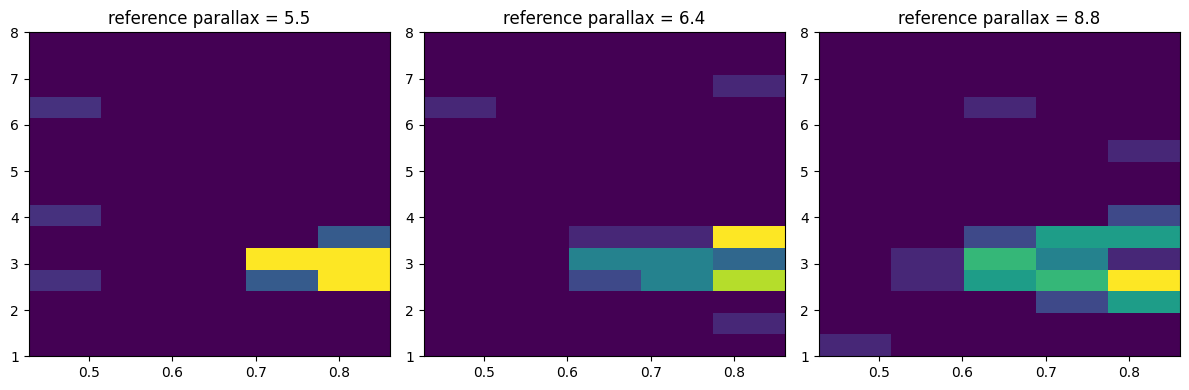

In [30]:
fig, axs = plt.subplots(1,3, figsize=(12,4), sharex=True)

logps = np.log10(imported_cube["meta"]["periods"])
yrange = (logps[-1], logps[0])

plxs = list(imported_cube["cube"].keys())

for i in range(3):
    lams = imported_cube["meta"]["qs"][i]
    xrange = np.array((lams[0], lams[-1]))**(1/4)
    extent = [*xrange, *yrange]
    extent = [float(e) for e in extent]
    axs[i].imshow(imported_cube["data"][plxs[i]][:,:,1], extent=extent, aspect="auto")
    axs[i].set_title("reference parallax = {:.1f}".format(plxs[i]))
    axs[i].invert_yaxis()

plt.tight_layout()

## "TRIAL" SCHEME

size: 25x10x25
compare no dropout to 10 dropout

no dropout: 7:54

10 dropout: 5.36

took 70% of the time

"trial orbit solutions" save time yippee

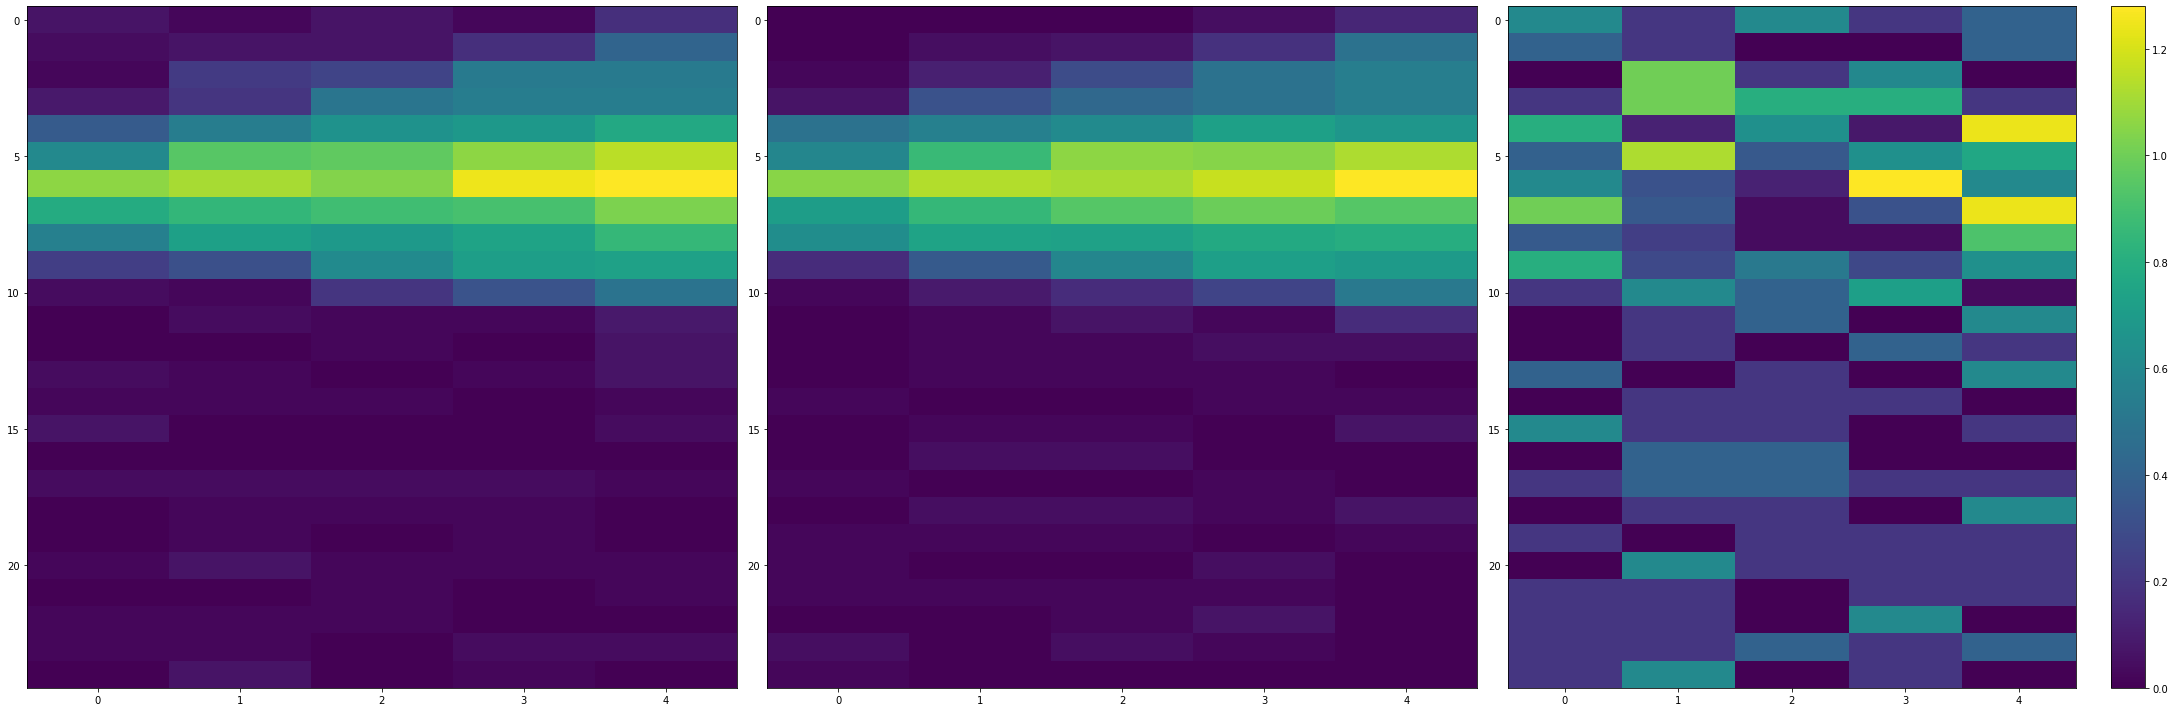

In [38]:
fig, axs = plt.subplots(1,3,figsize=(31,10))
imported_cube_l = pickle.load(open("./data/cube_test_l.pkl", "rb"))
image_l = np.mean(imported_cube_l["cube"], axis=2)
imported_cube_h = pickle.load(open("./data/cube_test_h.pkl", "rb"))
image_h = np.mean(imported_cube_h["cube"], axis=2)

axs[0].imshow(image_l, aspect="auto")
axs[1].imshow(image_h, aspect="auto")
cb = axs[2].imshow(abs(image_l-image_h), aspect="auto")
plt.colorbar(cb)
plt.tight_layout()

## test

In [4]:
imported_cube = pickle.load(open("./data/2025-12-02_mdwarf_circular_3plx.pkl", "rb"))

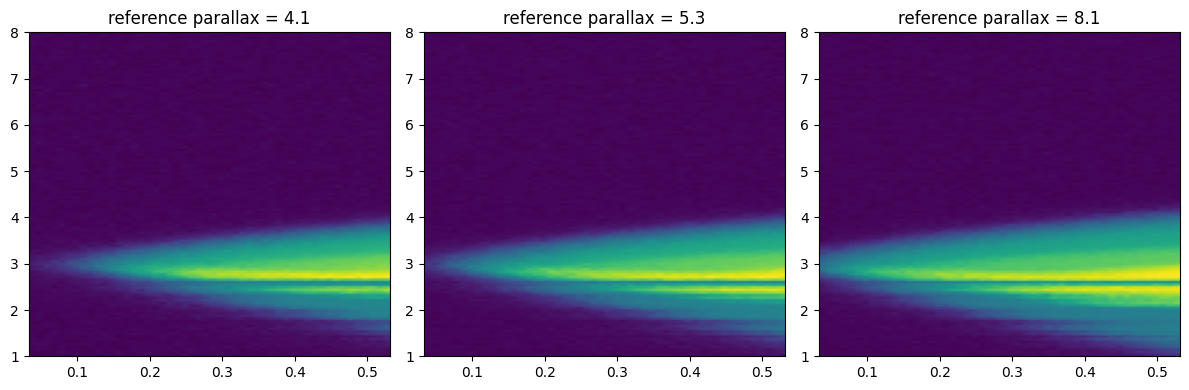

In [5]:
fig, axs = plt.subplots(1,3, figsize=(12,4), sharex=True)

logps = np.log10(imported_cube["meta"]["periods"])
yrange = (logps[-1], logps[0])

plxs = list(imported_cube["cube"].keys())

for i in range(3):
    lams = imported_cube["meta"]["qs"][i]
    xrange = np.array((lams[0], lams[-1]))
    extent = [*xrange, *yrange]
    extent = [float(e) for e in extent]
    axs[i].imshow(np.mean(imported_cube["cube"][plxs[i]], axis=2), extent=extent, aspect="auto")
    axs[i].set_title("reference parallax = {:.1f}".format(plxs[i]))
    axs[i].invert_yaxis()
    
plt.tight_layout()

## nice cube plot

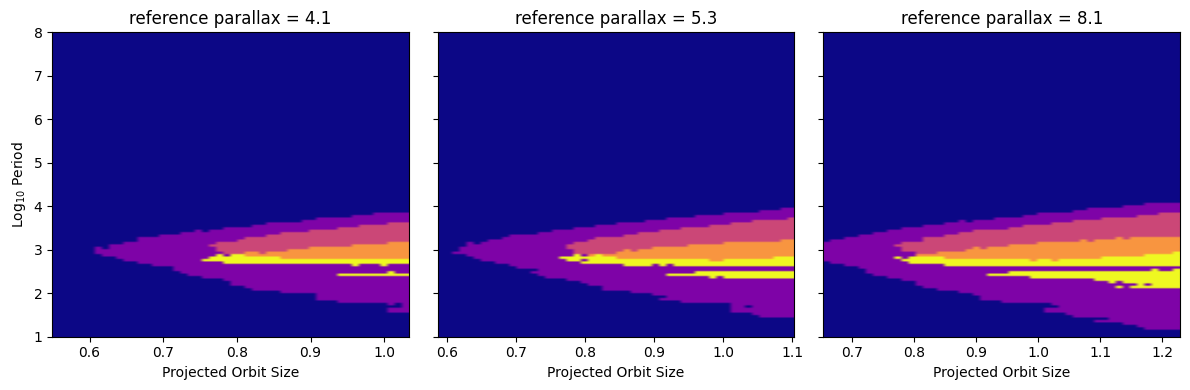

In [6]:
# MAKE PLOT
fig, axs = plt.subplots(1,3, figsize=(12,4), sharey=True);
axs[0].set_ylabel(r"$\text{Log}_{10}$ Period");
for i, ax in enumerate(axs):
    lams = imported_cube["meta"]["lambdas"][i]**(1/4)
    xrange = np.array((lams[0], lams[-1]))
    logps = np.log10(imported_cube["meta"]["periods"])
    yrange = (logps[-1], logps[0])
    extent = [*xrange, *yrange]
    extent = [float(e) for e in extent]

    colorcube = np.argmax(imported_cube["data"][plxs[i]], axis=2)
    ax.imshow(colorcube, extent=extent, aspect="auto", cmap="plasma");
    ax.invert_yaxis()
    ax.set_xlabel("Projected Orbit Size");
    ax.set_title("reference parallax = {:.1f}".format(plxs[i]))
fig.tight_layout()